
=== LFP DATAFRAME PREVIEW ===
          CH_0  CH_1  CH_2  CH_3  CH_4  ...  CH_62  CH_63  CH_64  CH_65  CH_66
Time (s)                                ...                                   
0.0000     287   -14   290   107  -155  ...    118    438   6782   5844  11769
0.0008     580   -42   613   284  -305  ...    259    930  13847  11916  24001
0.0016     578     0   597   263  -263  ...    284    956  13200  11316  22810
0.0024     599     7   558   160  -283  ...    278   1090  13069  11198  22547
0.0032     578   -46   543   188  -365  ...    299   1146  13295  11383  22887
0.0040     597    48   633   202  -358  ...    276   1063  13211  11316  22725
0.0048     561    15   599    71  -351  ...    203    978  13236  11331  22736
0.0056     492  -103   493    23  -365  ...    119    985  13263  11310  22760
0.0064     476  -176   394    43  -355  ...     57    894  13240  11312  22749
0.0072     374  -209   345   -87  -355  ...     44    839  13237  11338  22751

[10 rows x 67 column

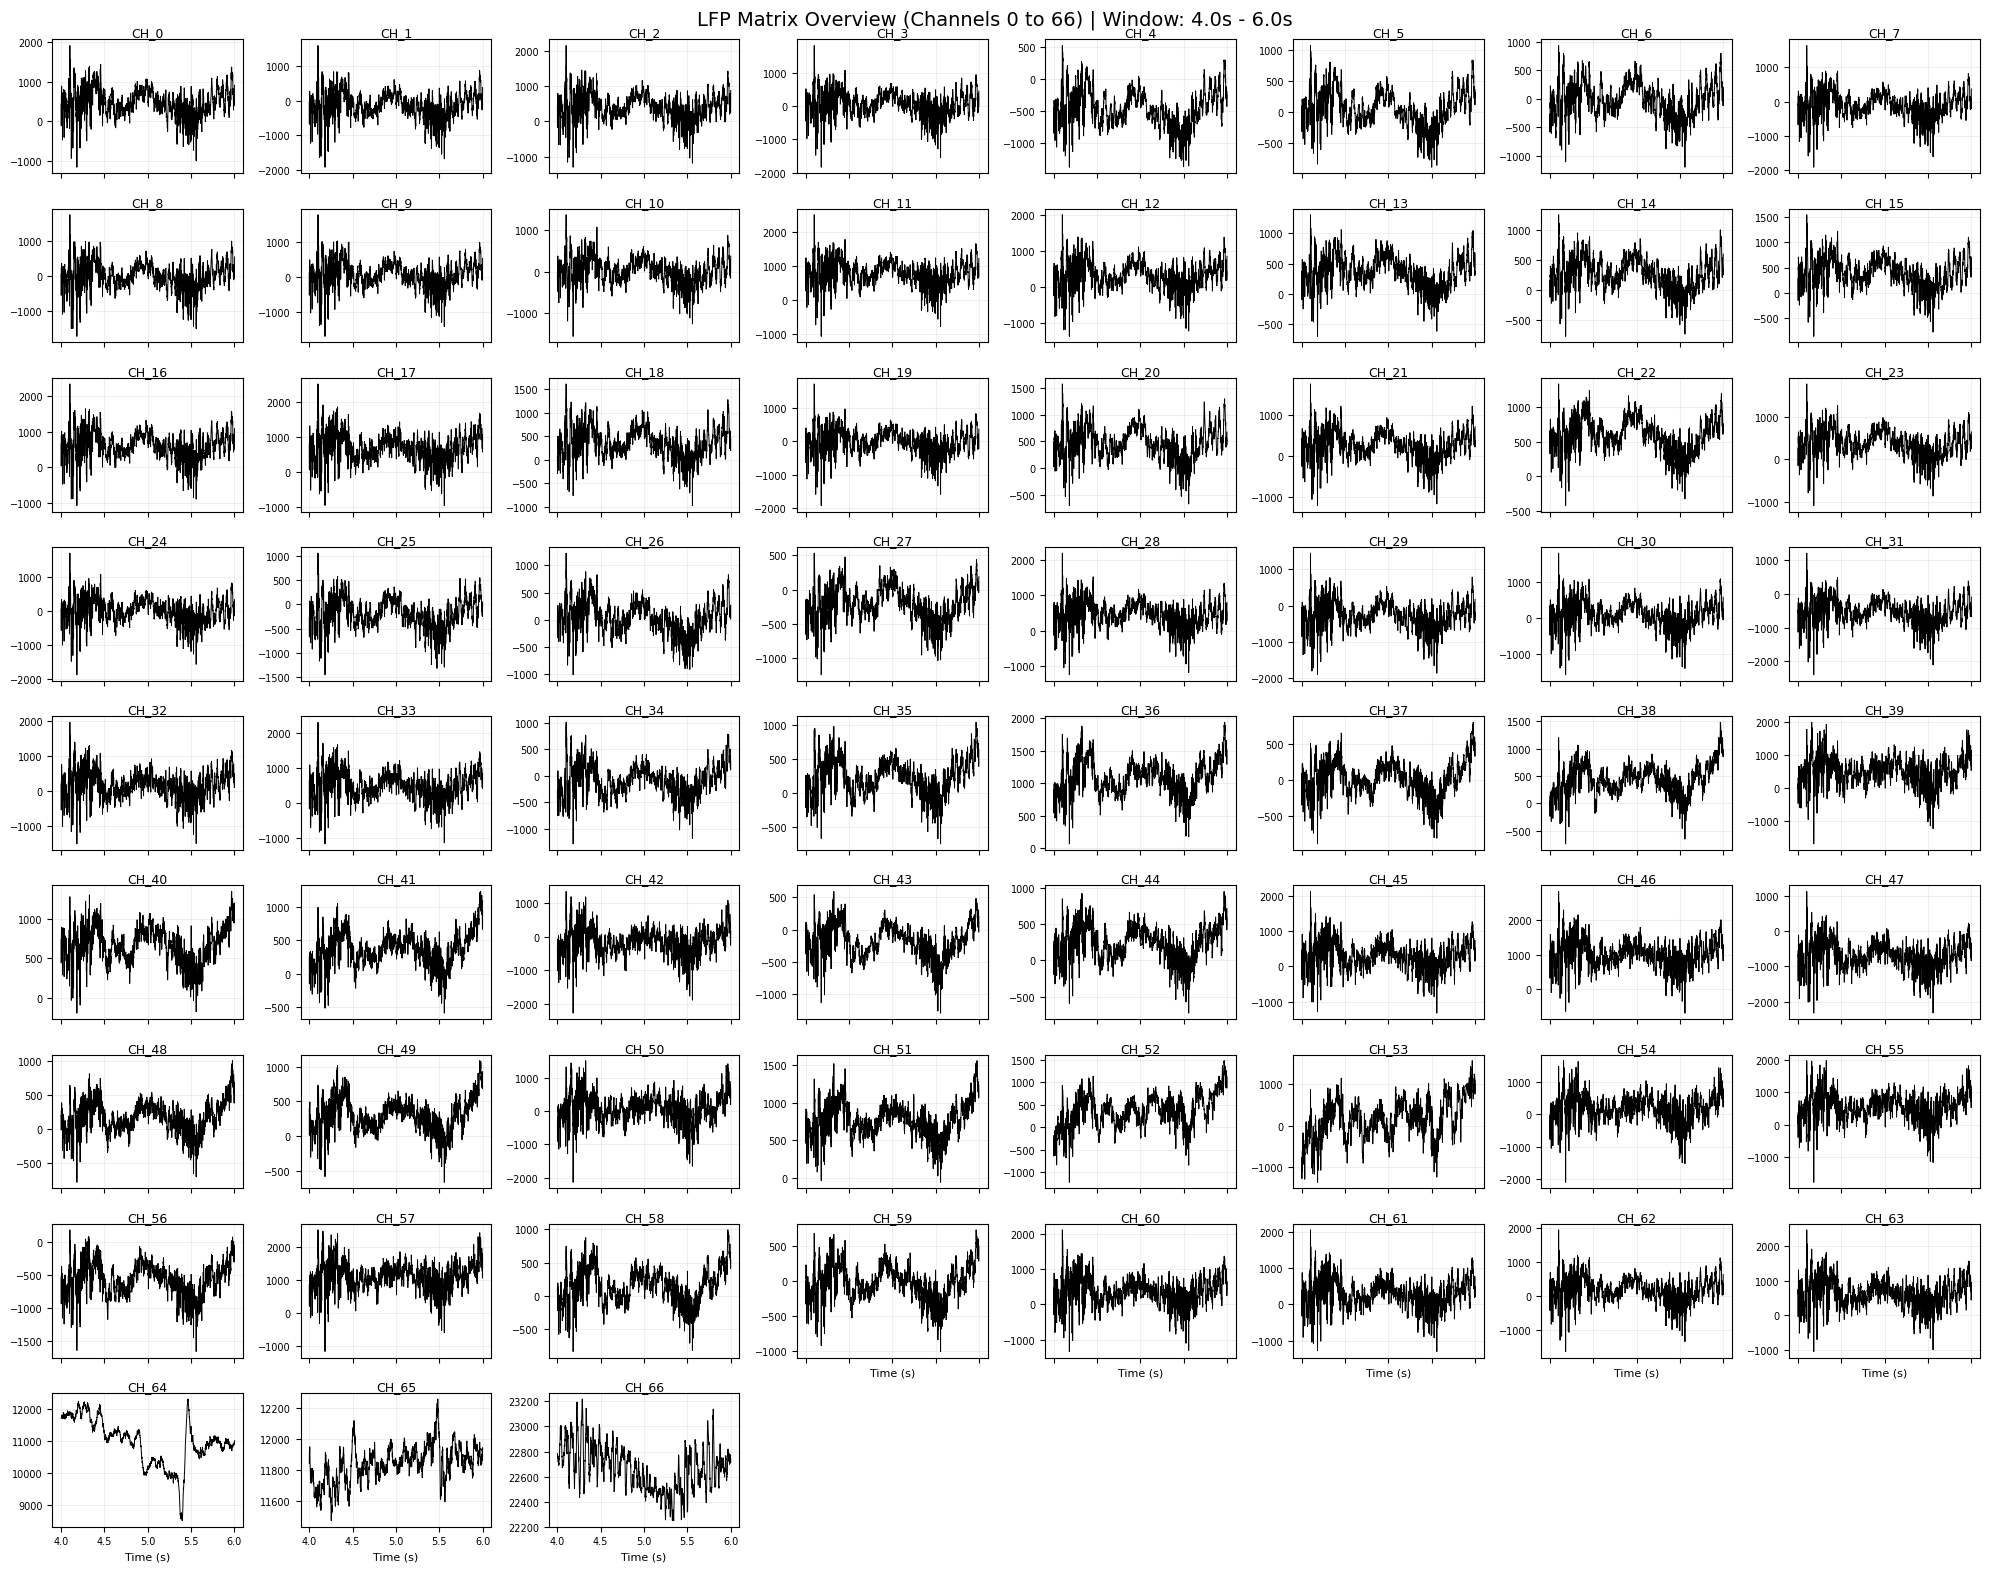

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Configuration ---
filename = r"C:\Users\laboratorio\Documents\GitHub\LFP-extraction-electrophysiology\LFP_output\output_file.lfp"
fs_lfp = 1250  
dtype = 'int16'
n_channels = 67 

# --- Data Loading & Validation ---
data = np.fromfile(filename, dtype=dtype)
total_points = len(data)

if total_points % n_channels != 0:
    possible_channels = [i for i in range(1, 400) if total_points % i == 0]
    raise ValueError(f"Data length ({total_points}) is not divisible by n_channels ({n_channels}). Possible factors: {possible_channels}")

n_samples = total_points // n_channels
data = data.reshape((n_samples, n_channels))

# --- Pandas DataFrame Construction ---
column_names = [f'CH_{i}' for i in range(n_channels)]
df = pd.DataFrame(data, columns=column_names)
df.index = np.arange(n_samples) / fs_lfp
df.index.name = 'Time (s)'

# --- Data Inspection (Tabular Print) ---
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 1000)
print("\n=== LFP DATAFRAME PREVIEW ===")
print(df.head(10))  # First 10 rows
print("\n=== DATA DESCRIPTIVE STATISTICS ===")
print(df.describe().loc[['mean', 'std', 'min', 'max']]) 

# --- Data Visualization (Subplot Grid) ---
t_start, t_stop = 4.0, 6.0
df_window = df.loc[t_start:t_stop]

# Grid geometry configuration (e.g., 9 rows x 8 columns = 72 slots for 67 channels)
n_rows = 9
n_cols = 8

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16), sharex=True)
axes = axes.flatten()

for i in range(n_channels):
    ax = axes[i]
    ax.plot(df_window.index, df_window[f'CH_{i}'], linewidth=0.7, color='black')
    ax.set_title(f'CH_{i}', fontsize=9, pad=2)
    ax.tick_params(axis='both', which='major', labelsize=7)
    ax.grid(True, alpha=0.2)
    
    # Labeling constraints for cleaner layout
    if i >= (n_rows - 1) * n_cols or i >= n_channels - n_cols:
        ax.set_xlabel('Time (s)', fontsize=8)

# Disable unused axis slots in the grid
for j in range(n_channels, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"LFP Matrix Overview (Channels 0 to {n_channels-1}) | Window: {t_start}s - {t_stop}s", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

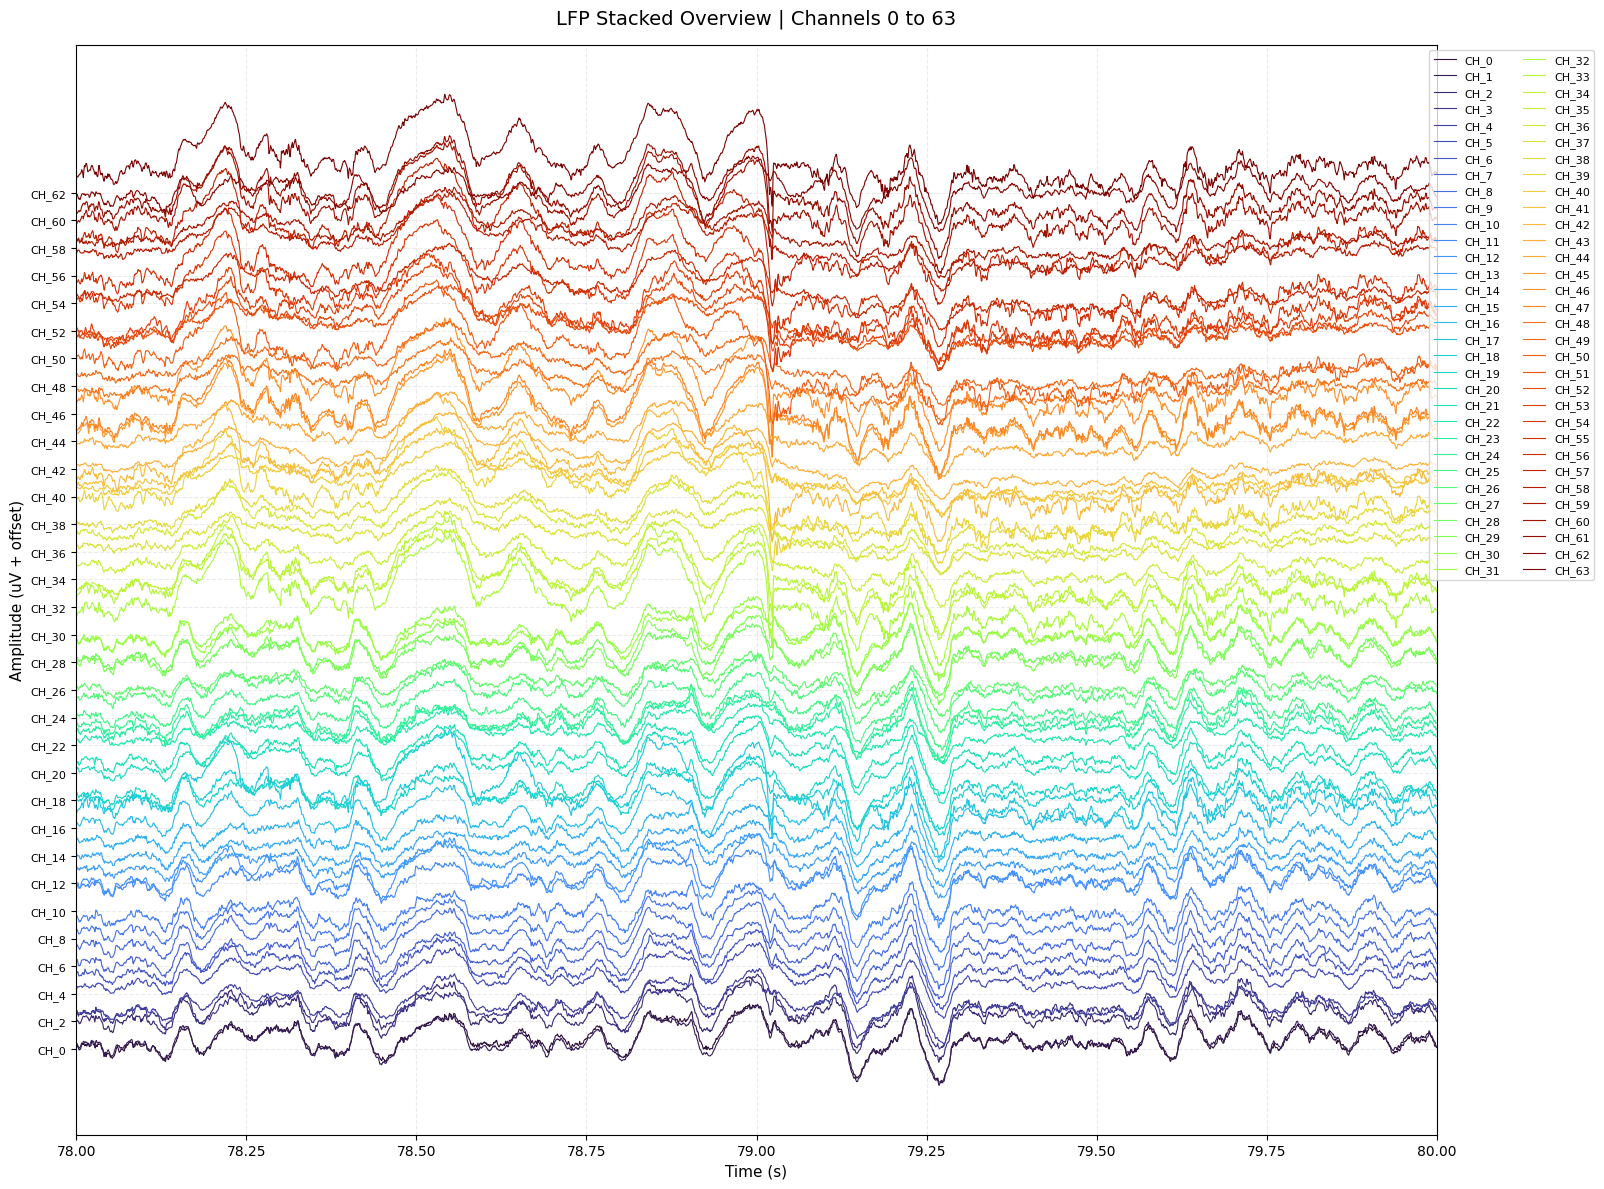

In [2]:
# --- Visualization: First 64 Channels Stacked ---
t_start, t_stop = 78.0, 80.0
n_plot_channels = 64
offset_value = 600  # Adjust this value if traces overlap too much
df_lfp = df.iloc[:, :n_plot_channels] # Select the first 64 channels

# Slice time window 
df_window = df_lfp.loc[t_start:t_stop]

# Apply vertical offset to separate channels cleanly
offsets = np.arange(n_plot_channels) * offset_value
df_offset = df_window + offsets

# Plotting Configuration
fig, ax = plt.subplots(figsize=(16, 12))

# Use a continuous colormap to generate distinct colors for all 64 channels
colors = plt.cm.turbo(np.linspace(0, 1, n_plot_channels))

for i, col in enumerate(df_offset.columns):
    ax.plot(df_offset.index, df_offset[col], color=colors[i], linewidth=0.8, label=col)

# Layout adjustments
ax.set_title(f"LFP Stacked Overview | Channels 0 to {n_plot_channels-1}", fontsize=14, pad=15)
ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Amplitude (uV + offset)", fontsize=11)
ax.set_xlim(t_start, t_stop)
ax.grid(True, alpha=0.25, linestyle='--')

# Match Y-ticks with channel positions for instant identification
ax.set_yticks(offsets[::2])  # Step by 2 to prevent Y-axis text crowding
ax.set_yticklabels(df_offset.columns[::2], fontsize=8)

# Optimize legend to display in multiple columns without blocking data
ax.legend(loc='upper right', bbox_to_anchor=(1.12, 1.0), ncol=2, fontsize=8, frameon=True)

plt.tight_layout()
plt.show()

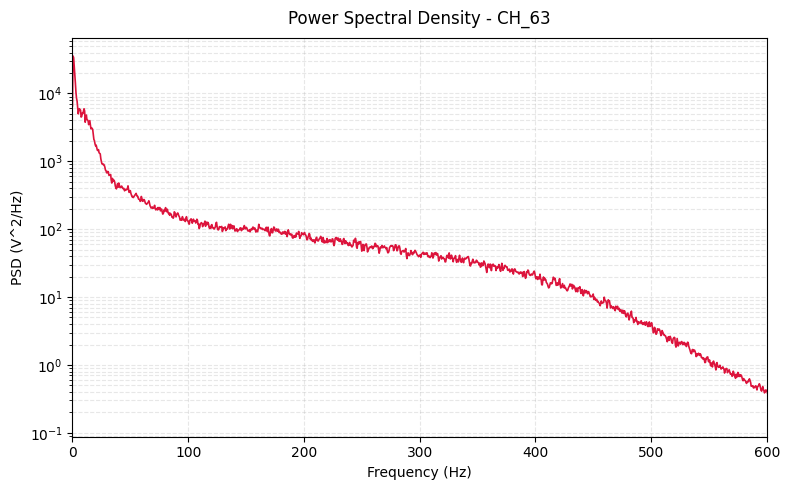

In [3]:
# --- Power Spectral Density (PSD) Analysis ---
from scipy import signal

ch_name = 'CH_63'  
nperseg_val = int(fs_lfp * 2)

# Extract raw numpy array using .values to avoid Pandas indexing conflicts in SciPy
channel_data = df_lfp[ch_name].values

frequencies, psd = signal.welch(channel_data, fs=fs_lfp, nperseg=nperseg_val)

plt.figure(figsize=(8, 5))
plt.semilogy(frequencies, psd, color='crimson', linewidth=1.2)

# Graph layout and constraints
plt.title(f"Power Spectral Density - {ch_name}", fontsize=12, pad=10)
plt.xlabel("Frequency (Hz)", fontsize=10)
plt.ylabel("PSD (V^2/Hz)", fontsize=10)
plt.xlim(0, 600) 
plt.grid(True, which="both", alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

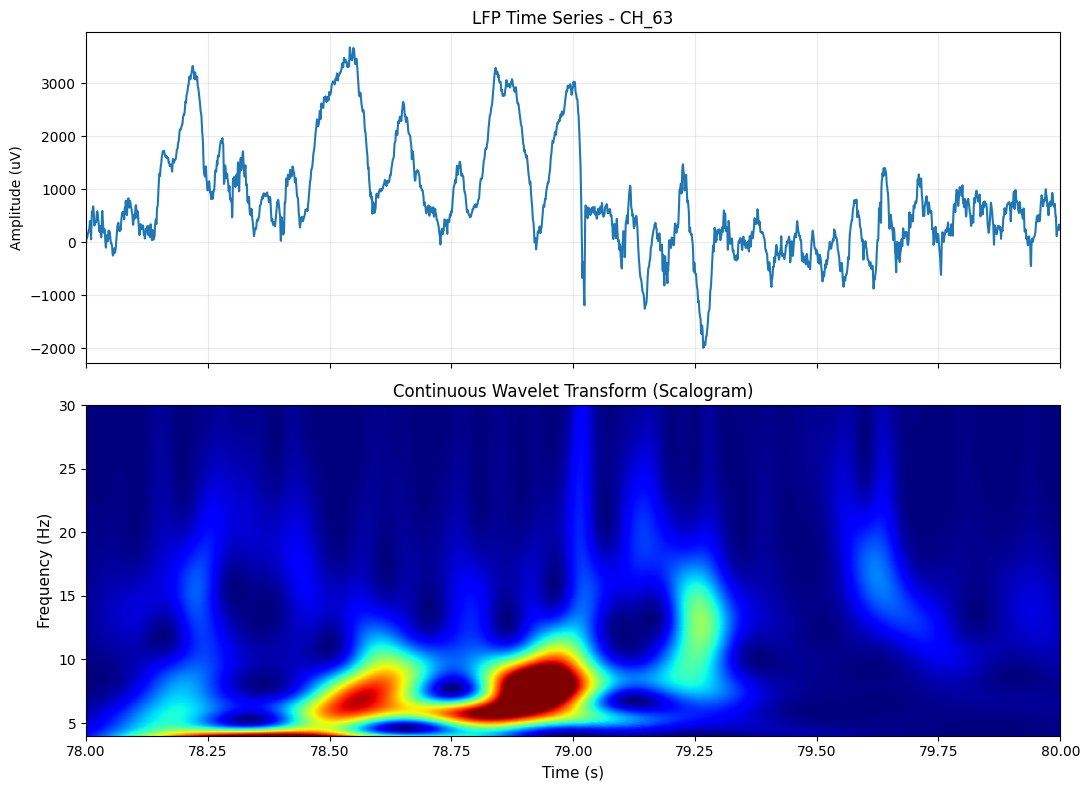

In [4]:
# --- Continuous Wavelet Transform (CWT) Analysis ---
import pywt

ch_name = 'CH_63'
min_freq, max_freq = 4, 30
step_freq = 0.1

# Frequency and scale definitions
num_freqs_desired = int((max_freq - min_freq) / step_freq) + 1
freqs = np.linspace(min_freq, max_freq, num_freqs_desired)

dt = 1 / fs_lfp
wav = pywt.ContinuousWavelet('cmor1.0-1.0')
central_freq = pywt.central_frequency(wav)
scales = central_freq / (freqs * dt)

# Extract time-locked window data directly from df_window
segment_time = df_window.index.values
raw_signal = df_window[ch_name].values

# Compute CWT using the sliced window data
W, _ = pywt.cwt(raw_signal, scales, wav, method='fft', sampling_period=dt)
cwt_freqs = pywt.scale2frequency(wav, scales) / dt
W = np.abs(W)**2

# Plotting Raw Signal and Scalogram
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Top Plot: Raw LFP Signal
ax1.plot(segment_time, raw_signal)
ax1.set_ylabel('Amplitude (uV)')
ax1.set_title(f'LFP Time Series - {ch_name}', fontsize=12)
ax1.grid(True, alpha=0.25)

# Bottom Plot: Time-Frequency Scalogram
im = ax2.imshow(W, 
                extent=[segment_time[0], segment_time[-1], cwt_freqs.min(), cwt_freqs.max()],
                aspect='auto', cmap='jet', vmax=np.percentile(W, 99), vmin=0,
                origin='lower')

ax2.set_xlabel('Time (s)', fontsize=11)
ax2.set_ylabel('Frequency (Hz)', fontsize=11)
ax2.set_title('Continuous Wavelet Transform (Scalogram)', fontsize=12)
ax2.set_ylim(min_freq, max_freq)

# Layout and rendering
plt.xlim(t_start, t_stop)
plt.tight_layout()
plt.show()

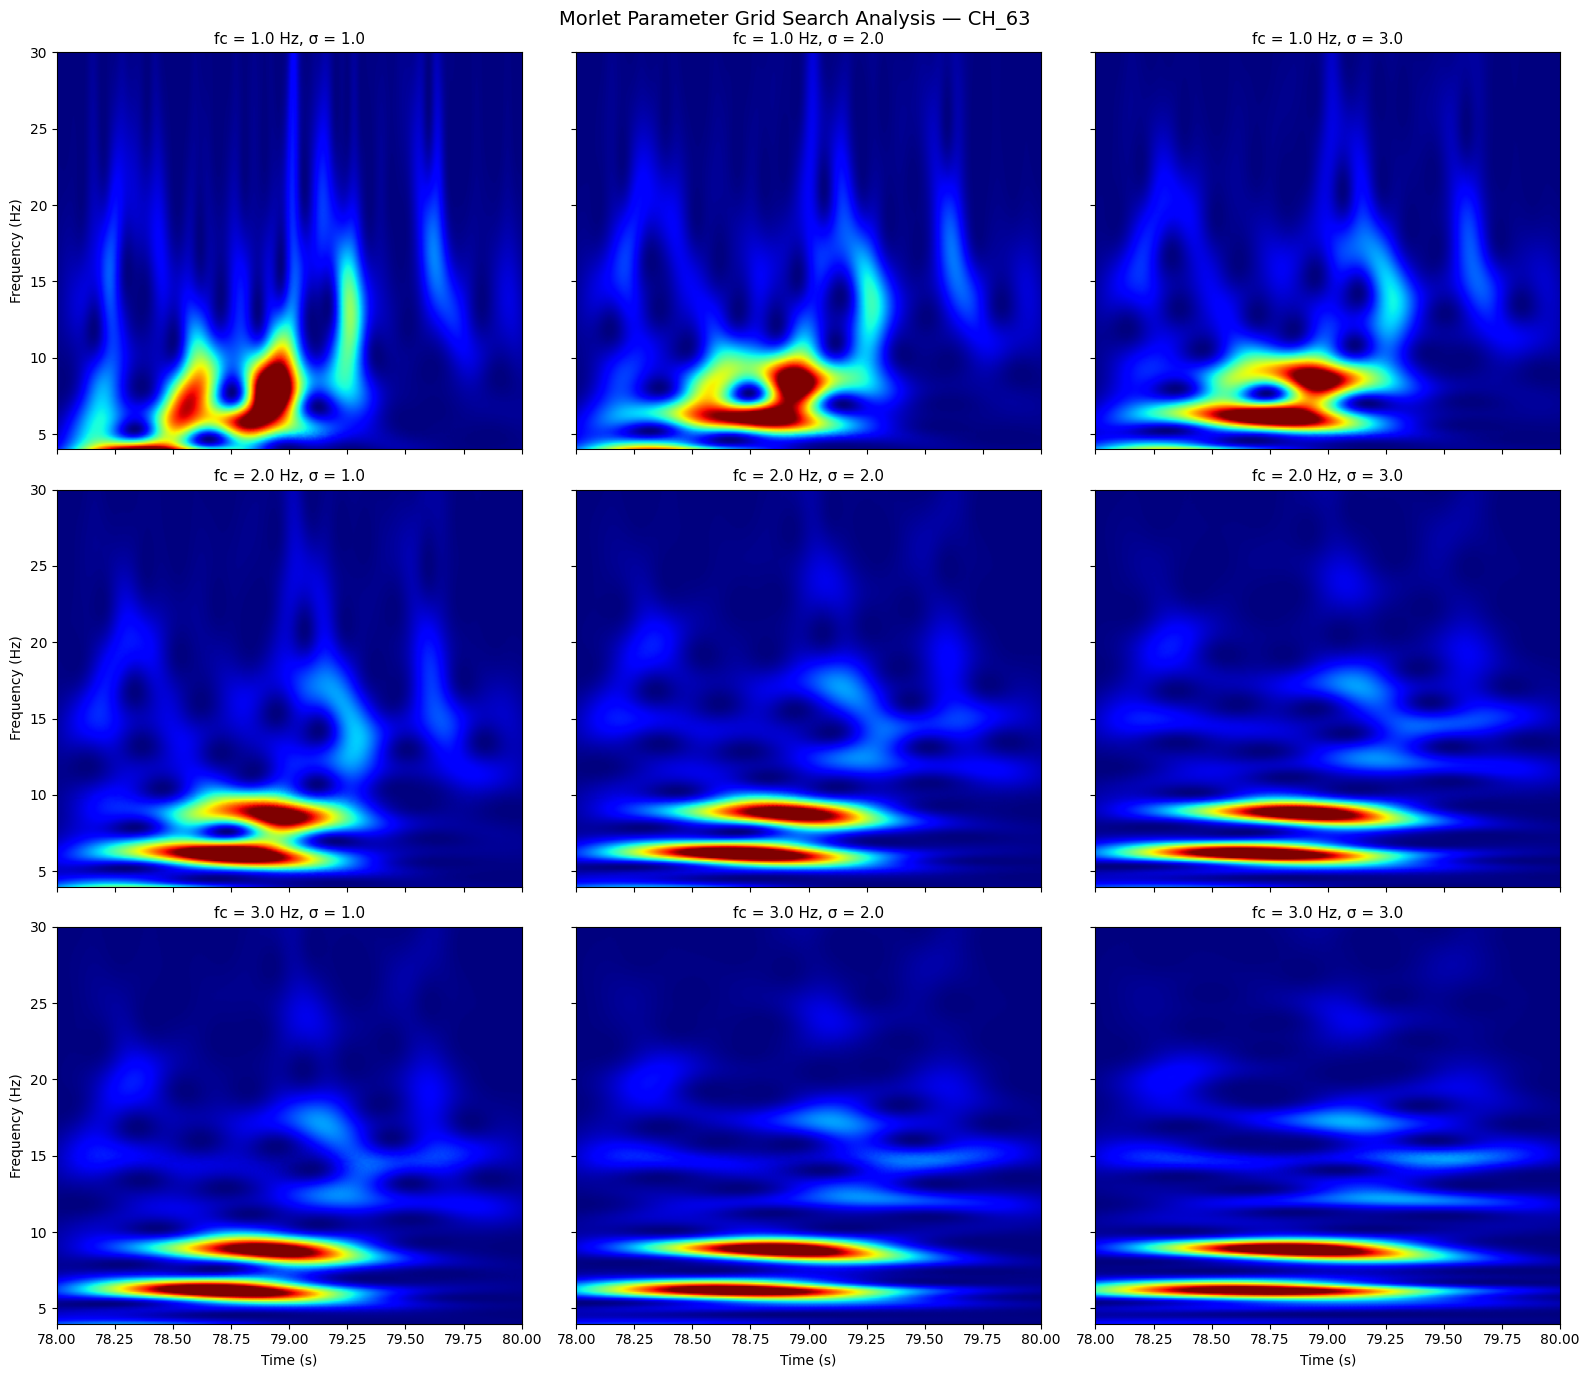

In [6]:
# --- Wavelet Parameter Optimization Grid (fc vs sigma) ---
ch_name = 'CH_63'
lfp_signal = df_window[ch_name].values
segment_time = df_window.index.values

fcs = [1.0, 2.0, 3.0]
sigmas = [1.0, 2.0, 3.0]

fig, axs = plt.subplots(len(fcs), len(sigmas), figsize=(16, 14), sharex=True, sharey=True)

for i, fc in enumerate(fcs):
    for j, sigma in enumerate(sigmas):
        # Dynamically compute scales for the specific fc
        scales = fc / (freqs * dt)
        wav_name = f'cmor{sigma}-{fc}'

        # Compute CWT
        W_i, _ = pywt.cwt(lfp_signal, scales, wav_name, method='fft', sampling_period=dt)
        cwt_freqs = pywt.scale2frequency(wav_name, scales) / dt
        W_i = np.abs(W_i)**2

        # Grid Plotting
        ax = axs[i, j]
        im = ax.imshow(W_i,
                       extent=[segment_time[0], segment_time[-1], cwt_freqs.min(), cwt_freqs.max()],
                       aspect='auto', cmap='jet', vmax=np.percentile(W_i, 99), vmin=0,
                       origin='lower')
        
        # Labels and Metadata
        ax.set_title(f'fc = {fc} Hz, σ = {sigma}', fontsize=11)
        ax.set_xlim(t_start, t_stop)
        ax.set_ylim(min_freq, max_freq)
        
        if i == len(fcs) - 1:
            ax.set_xlabel('Time (s)', fontsize=10)
        if j == 0:
            ax.set_ylabel('Frequency (Hz)', fontsize=10)

plt.suptitle(f"Morlet Parameter Grid Search Analysis — {ch_name}", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

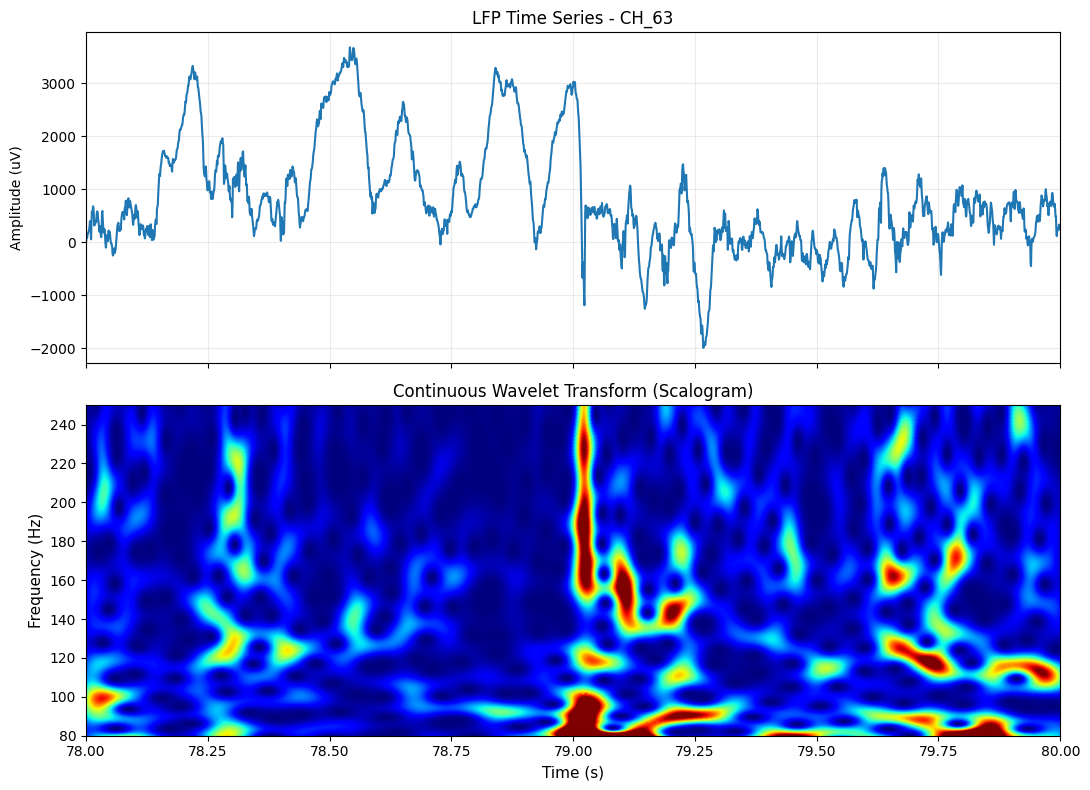

In [8]:
# --- Continuous Wavelet Transform (CWT) Analysis ---
import pywt

ch_name = 'CH_63'
min_freq, max_freq = 80, 250
step_freq = 0.1

# Frequency and scale definitions
num_freqs_desired = int((max_freq - min_freq) / step_freq) + 1
freqs = np.linspace(min_freq, max_freq, num_freqs_desired)

dt = 1 / fs_lfp
wav = pywt.ContinuousWavelet('cmor3.0-3.0')
central_freq = pywt.central_frequency(wav)
scales = central_freq / (freqs * dt)

# Extract time-locked window data directly from df_window
segment_time = df_window.index.values
raw_signal = df_window[ch_name].values

# Compute CWT using the sliced window data
W, _ = pywt.cwt(raw_signal, scales, wav, method='fft', sampling_period=dt)
cwt_freqs = pywt.scale2frequency(wav, scales) / dt
W = np.abs(W)**2

# Plotting Raw Signal and Scalogram
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Top Plot: Raw LFP Signal
ax1.plot(segment_time, raw_signal)
ax1.set_ylabel('Amplitude (uV)')
ax1.set_title(f'LFP Time Series - {ch_name}', fontsize=12)
ax1.grid(True, alpha=0.25)

# Bottom Plot: Time-Frequency Scalogram
im = ax2.imshow(W, 
                extent=[segment_time[0], segment_time[-1], cwt_freqs.min(), cwt_freqs.max()],
                aspect='auto', cmap='jet', vmax=np.percentile(W, 99), vmin=0,
                origin='lower')

ax2.set_xlabel('Time (s)', fontsize=11)
ax2.set_ylabel('Frequency (Hz)', fontsize=11)
ax2.set_title('Continuous Wavelet Transform (Scalogram)', fontsize=12)
ax2.set_ylim(min_freq, max_freq)

# Layout and rendering
plt.xlim(t_start, t_stop)
plt.tight_layout()
plt.show()

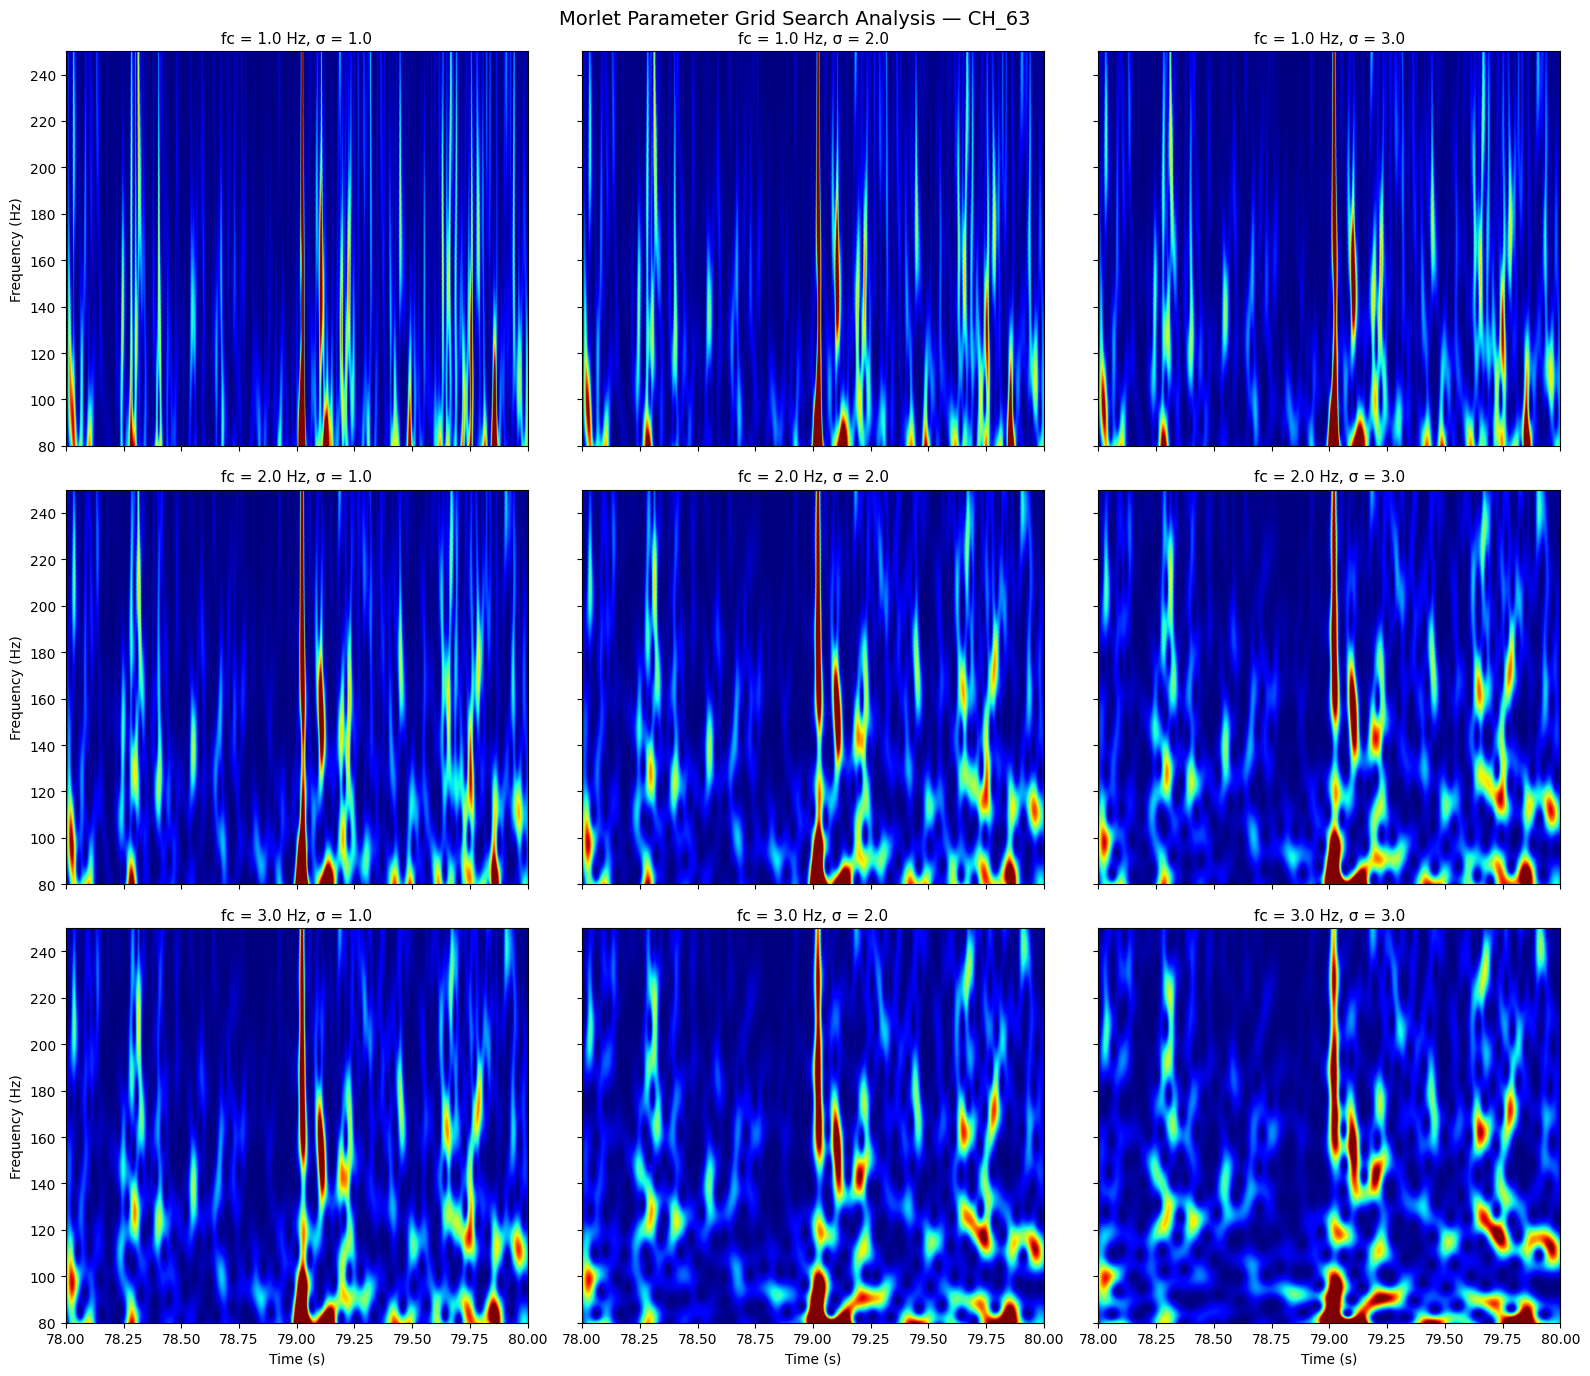

: 

In [ ]:
# --- Wavelet Parameter Optimization Grid (fc vs sigma) ---
ch_name = 'CH_63'
lfp_signal = df_window[ch_name].values
segment_time = df_window.index.values

fcs = [1.0, 2.0, 3.0]
sigmas = [1.0, 2.0, 3.0]

fig, axs = plt.subplots(len(fcs), len(sigmas), figsize=(16, 14), sharex=True, sharey=True)

for i, fc in enumerate(fcs):
    for j, sigma in enumerate(sigmas):
        # Dynamically compute scales for the specific fc
        scales = fc / (freqs * dt)
        wav_name = f'cmor{sigma}-{fc}'

        # Compute CWT
        W_i, _ = pywt.cwt(lfp_signal, scales, wav_name, method='fft', sampling_period=dt)
        cwt_freqs = pywt.scale2frequency(wav_name, scales) / dt
        W_i = np.abs(W_i)**2

        # Grid Plotting
        ax = axs[i, j]
        im = ax.imshow(W_i,
                       extent=[segment_time[0], segment_time[-1], cwt_freqs.min(), cwt_freqs.max()],
                       aspect='auto', cmap='jet', vmax=np.percentile(W_i, 99), vmin=0,
                       origin='lower')
        
        # Labels and Metadata
        ax.set_title(f'fc = {fc} Hz, σ = {sigma}', fontsize=11)
        ax.set_xlim(t_start, t_stop)
        ax.set_ylim(min_freq, max_freq)
        
        if i == len(fcs) - 1:
            ax.set_xlabel('Time (s)', fontsize=10)
        if j == 0:
            ax.set_ylabel('Frequency (Hz)', fontsize=10)

plt.suptitle(f"Morlet Parameter Grid Search Analysis — {ch_name}", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()